         date      time                ID  transectStart_X_x  \
0  1984-06-23  16:13:17  usa_TX_0001_0001          -93.83873   
1  1984-09-11  16:14:33  usa_TX_0001_0001          -93.83873   
2  1984-11-30  16:14:46  usa_TX_0001_0001          -93.83873   
3  1985-01-01  16:14:42  usa_TX_0001_0001          -93.83873   
4  1985-03-22  16:15:16  usa_TX_0001_0001          -93.83873   

   transectStart_Y_x  transectEnd_X_x  transectEnd_Y_x   distance  slope  \
0           29.67942       -93.838165        29.676622  108.79432  0.035   
1           29.67942       -93.838165        29.676622   85.88579  0.035   
2           29.67942       -93.838165        29.676622   70.05994  0.035   
3           29.67942       -93.838165        29.676622   75.72523  0.035   
4           29.67942       -93.838165        29.676622   88.70066  0.035   

       tide  ...  transectEnd_X_y  transectEnd_Y_y    lon_mid    lat_mid  \
0  0.145488  ...       -93.838165        29.676622 -93.838448  29.678021   
1 -0.0

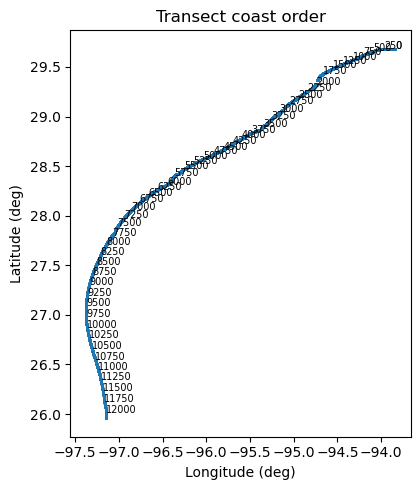

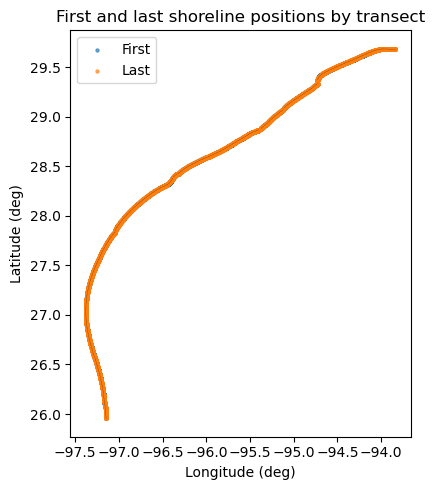

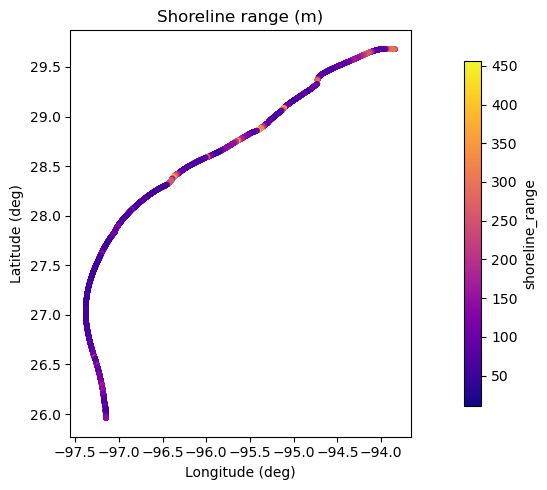

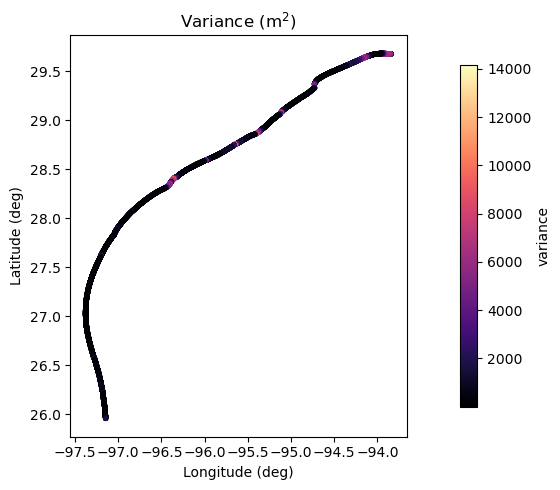

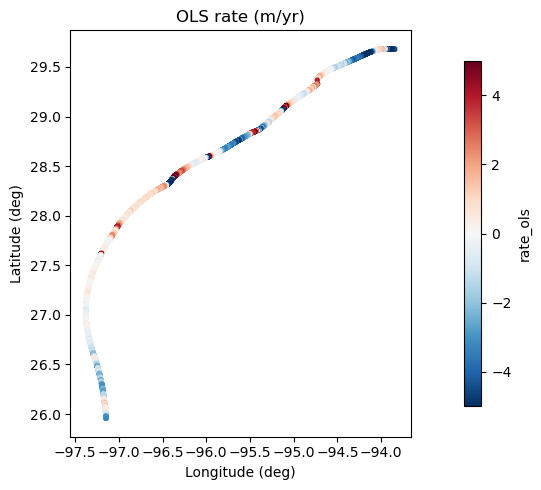

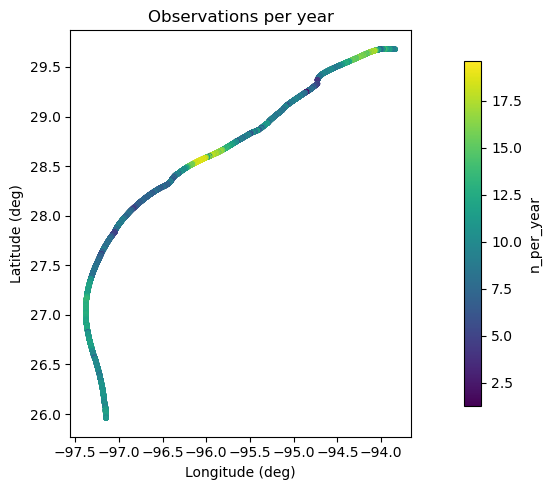

In [1]:
"""
preprocess_shorelines

Utilities for analyzing CoastSat/DSAS-style satellite-derived shoreline CSV files.

Recommended workflow
--------------------
One-time preprocessing
1. Read and prepare shoreline observations from raw CSV
2. Build a transect geometry table
3. Add along-coast distance metadata
4. Merge transect metadata back onto observations
5. Compute per-transect statistics
6. Save:
   - processed shoreline observations
   - transect geometry table
   - transect statistics table

Analysis notebooks (separate) might include:
------------------
Read the saved processed tables and perform:
- trend analyses
- LOWESS / LOESS decomposition
- heat maps
- storm annotations
- nourishment overlays

Notes
-----
- Cross-shore shoreline position is taken from the 'distance' column (meters).
- Landward/seaward should be defined from 'distance', not lon/lat:
    landward = min(distance)
    seaward  = max(distance)
- Geographic lon/lat are used for plotting and for constructing along-coast distance.
- For Texas, a projected CRS like EPSG:3083 is convenient for along-coast distance.

ChatGPT + csherwood@usgs.gov
------
Refactored for the Texas shoreline workflow
"""

from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geopandas as gpd
from scipy.stats import theilslopes as scipy_theilslopes

# optional sklearn import only if needed later
try:
    from sklearn.linear_model import TheilSenRegressor
except Exception:
    TheilSenRegressor = None


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

@dataclass
class AnalysisConfig:
    datetime_col: str = "datetime"
    id_col: str = "ID"
    distance_col: str = "distance"
    lon_col: str = "shoreline_x"
    lat_col: str = "shoreline_y"
    start_x_col: str = "transectStart_X"
    start_y_col: str = "transectStart_Y"
    end_x_col: str = "transectEnd_X"
    end_y_col: str = "transectEnd_Y"
    proj_crs: str = "EPSG:3083"
    source_crs: str = "EPSG:4326"


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------

def _require_package(obj, package_name: str, feature: str) -> None:
    if obj is None:
        raise ImportError(
            f"{feature} requires '{package_name}', but it is not installed."
        )


def _decimal_year(dt: pd.Series) -> pd.Series:
    year = dt.dt.year
    doy = dt.dt.dayofyear
    return year + (doy - 1) / 365.25


def _transect_numeric_id(id_value: str) -> Tuple[int, int]:
    m = re.search(r"_(\d{4})_(\d{4})$", str(id_value))
    if m:
        return int(m.group(1)), int(m.group(2))
    return (10**9, 10**9)


def _geographic_aspect(lat_deg) -> float:
    mean_lat = np.nanmean(np.asarray(lat_deg))
    return 1.0 / np.cos(np.deg2rad(mean_lat))


def _ols_fit(t: np.ndarray, x: np.ndarray):
    mask = np.isfinite(t) & np.isfinite(x)
    t = np.asarray(t)[mask]
    x = np.asarray(x)[mask]

    if t.size < 3:
        return np.nan, np.nan, np.nan, np.nan

    p = np.polyfit(t, x, 1)
    slope, intercept = float(p[0]), float(p[1])
    xhat = slope * t + intercept
    ss_res = float(np.sum((x - xhat) ** 2))
    ss_tot = float(np.sum((x - np.mean(x)) ** 2))
    r2 = np.nan if ss_tot == 0 else 1.0 - ss_res / ss_tot
    rmse = float(np.sqrt(np.mean((x - xhat) ** 2)))
    return slope, intercept, r2, rmse


def _theil_sen_pairwise(t: np.ndarray, x: np.ndarray):
    mask = np.isfinite(t) & np.isfinite(x)
    t = np.asarray(t)[mask]
    x = np.asarray(x)[mask]

    n = t.size
    if n < 5:
        return np.nan, np.nan

    dt = t[np.newaxis, :] - t[:, np.newaxis]
    dx = x[np.newaxis, :] - x[:, np.newaxis]
    iu = np.triu_indices(n, k=1)
    valid = dt[iu] != 0
    slopes = dx[iu][valid] / dt[iu][valid]

    if slopes.size == 0:
        return np.nan, np.nan

    slope = float(np.median(slopes))
    intercept = float(np.median(x - slope * t))
    return slope, intercept


# -----------------------------------------------------------------------------
# Reading / preparation
# -----------------------------------------------------------------------------

def read_raw_shoreline_csv(
    filename: str | Path,
    low_memory: bool = False,
) -> pd.DataFrame:
    return pd.read_csv(filename, low_memory=low_memory)


def prepare_shoreline_df(
    df: pd.DataFrame,
    config: AnalysisConfig = AnalysisConfig(),
) -> pd.DataFrame:
    """
    Prepare raw shoreline dataframe.

    Adds:
    - datetime
    - year
    - t (decimal year)
    """
    out = df.copy()

    out[config.datetime_col] = pd.to_datetime(
        out["date"].astype(str) + " " + out["time"].astype(str),
        errors="coerce",
    )

    required = [
        config.datetime_col,
        config.id_col,
        config.distance_col,
        config.lon_col,
        config.lat_col,
        config.start_x_col,
        config.start_y_col,
        config.end_x_col,
        config.end_y_col,
    ]
    out = out.dropna(subset=required).copy()

    out["year"] = out[config.datetime_col].dt.year
    out["t"] = _decimal_year(out[config.datetime_col])

    out = out.sort_values([config.id_col, config.datetime_col]).reset_index(drop=True)
    return out


def read_and_prepare_shoreline_csv(
    filename: str | Path,
    config: AnalysisConfig = AnalysisConfig(),
    low_memory: bool = False,
) -> pd.DataFrame:
    df = read_raw_shoreline_csv(filename, low_memory=low_memory)
    return prepare_shoreline_df(df, config=config)


# -----------------------------------------------------------------------------
# Transect geometry / alongshore distance
# -----------------------------------------------------------------------------

def build_transect_table(
    df: pd.DataFrame,
    config: AnalysisConfig = AnalysisConfig(),
) -> pd.DataFrame:
    g = df.groupby(config.id_col, sort=False).first().reset_index()

    out = pd.DataFrame({
        config.id_col: g[config.id_col],
        config.start_x_col: g[config.start_x_col],
        config.start_y_col: g[config.start_y_col],
        config.end_x_col: g[config.end_x_col],
        config.end_y_col: g[config.end_y_col],
    })

    out["lon_mid"] = 0.5 * (out[config.start_x_col] + out[config.end_x_col])
    out["lat_mid"] = 0.5 * (out[config.start_y_col] + out[config.end_y_col])

    return out


def sort_transects_south_to_northeast(
    transects: pd.DataFrame,
    id_col: str = "ID",
    method: str = "id",
) -> pd.DataFrame:
    out = transects.copy()

    if method == "id":
        keys = out[id_col].map(_transect_numeric_id)
        out["_k1"] = [k[0] for k in keys]
        out["_k2"] = [k[1] for k in keys]
        out = out.sort_values(["_k1", "_k2", id_col]).drop(columns=["_k1", "_k2"])
    elif method == "latlon":
        out = out.sort_values(["lat_mid", "lon_mid"])
    elif method == "none":
        pass
    else:
        raise ValueError("method must be 'id', 'latlon', or 'none'")

    return out.reset_index(drop=True)


def add_alongshore_distance(
    transects: pd.DataFrame,
    proj_crs: str = "EPSG:3083",
    source_crs: str = "EPSG:4326",
    sort_method: str = "none",
    id_col: str = "ID",
) -> pd.DataFrame:
    """
    Add projected x/y and cumulative along-coast distance.

    Notes
    -----
    - If sort_method != 'none', transects are sorted before distances are computed.
    - Southernmost / first transect becomes s_km = 0.
    - coast_order follows row order after sorting.
    """
    _require_package(gpd, "geopandas", "add_alongshore_distance")

    out = transects.copy()

    if sort_method != "none":
        out = sort_transects_south_to_northeast(out, id_col=id_col, method=sort_method)

    gdf = gpd.GeoDataFrame(
        out.copy(),
        geometry=gpd.points_from_xy(out["lon_mid"], out["lat_mid"]),
        crs=source_crs,
    ).to_crs(proj_crs)

    out["x_proj"] = gdf.geometry.x
    out["y_proj"] = gdf.geometry.y

    dx = np.diff(out["x_proj"].to_numpy())
    dy = np.diff(out["y_proj"].to_numpy())
    ds = np.sqrt(dx**2 + dy**2)

    s_m = np.r_[0.0, np.cumsum(ds)]

    out["ds_m"] = np.r_[np.nan, ds]
    out["s_m"] = s_m
    out["s_km"] = s_m / 1000.0
    out["coast_order"] = np.arange(len(out), dtype=int)

    return out


def attach_transect_metadata(
    shoreline_df: pd.DataFrame,
    transects: pd.DataFrame,
    id_col: str = "ID",
) -> pd.DataFrame:
    """
    Merge transect-level metadata onto each shoreline observation.
    """
    cols_keep = [c for c in transects.columns if c != id_col]
    out = shoreline_df.merge(
        transects[[id_col] + cols_keep],
        on=id_col,
        how="left",
    )
    return out


# -----------------------------------------------------------------------------
# Per-transect statistics
# -----------------------------------------------------------------------------

def compute_basic_stats_group(group: pd.DataFrame) -> pd.Series:
    x = group["distance"].to_numpy(dtype=float)
    t = group["t"].to_numpy(dtype=float)
    years = group["year"].to_numpy(dtype=float)

    n = len(x)
    x_landward = np.nanmin(x)
    x_seaward = np.nanmax(x)

    t_first = np.nanmin(t)
    t_last = np.nanmax(t)
    duration_years = t_last - t_first if n > 1 else 0.0

    y_first = np.nanmin(years)
    y_last = np.nanmax(years)
    n_years_inclusive = (
        y_last - y_first + 1
        if np.isfinite(y_first) and np.isfinite(y_last)
        else np.nan
    )

    return pd.Series({
        "x_landward": x_landward,
        "x_seaward": x_seaward,
        "shoreline_range": x_seaward - x_landward,
        "variance": np.nanvar(x, ddof=1) if n > 1 else np.nan,
        "std": np.nanstd(x, ddof=1) if n > 1 else np.nan,
        "n_obs": n,
        "n_per_year": n / n_years_inclusive if n_years_inclusive and n_years_inclusive > 0 else np.nan,
        "year_first": y_first,
        "year_last": y_last,
        "t_first": t_first,
        "t_last": t_last,
        "duration_years": duration_years,
        "x_first": x[0],
        "x_last": x[-1],
    })


def compute_basic_stats(df: pd.DataFrame, id_col: str = "ID") -> pd.DataFrame:
    cols = ["distance", "year", "t"]
    return df.groupby(id_col)[cols].apply(compute_basic_stats_group).reset_index()


def fit_ols_group(group: pd.DataFrame) -> pd.Series:
    x = group["distance"].to_numpy(dtype=float)
    t = group["t"].to_numpy(dtype=float)

    slope, intercept, r2, rmse = _ols_fit(t, x)
    return pd.Series({
        "rate_ols": slope,
        "intercept_ols": intercept,
        "r2_ols": r2,
        "rmse_ols": rmse,
    })


def compute_ols_stats(df: pd.DataFrame, id_col: str = "ID") -> pd.DataFrame:
    cols = ["distance", "t"]
    return df.groupby(id_col)[cols].apply(fit_ols_group).reset_index()


def fit_theilsen_group(
    group: pd.DataFrame,
    method: str = "pairwise",
    random_state: int = 0,
    max_subpopulation: int = 10_000,
) -> pd.Series:
    x = group["distance"].to_numpy(dtype=float)
    t = group["t"].to_numpy(dtype=float)

    if method == "pairwise":
        slope, intercept = _theil_sen_pairwise(t, x)
    elif method == "scipy":
        mask = np.isfinite(t) & np.isfinite(x)
        t2 = t[mask]
        x2 = x[mask]
        if t2.size < 5:
            slope, intercept = np.nan, np.nan
        else:
            slope, intercept, _, _ = scipy_theilslopes(x2, t2)
            slope = float(slope)
            intercept = float(intercept)
    elif method == "sklearn":
        _require_package(TheilSenRegressor, "scikit-learn", "fit_theilsen_group(method='sklearn')")
        mask = np.isfinite(t) & np.isfinite(x)
        t2 = t[mask].reshape(-1, 1)
        x2 = x[mask]
        if x2.size < 5:
            slope, intercept = np.nan, np.nan
        else:
            model = TheilSenRegressor(
                random_state=random_state,
                max_subpopulation=max_subpopulation,
            )
            model.fit(t2, x2)
            slope = float(model.coef_[0])
            intercept = float(model.intercept_)
    else:
        raise ValueError("method must be 'pairwise', 'scipy', or 'sklearn'")

    return pd.Series({
        "rate_ts": slope,
        "intercept_ts": intercept,
    })


def compute_theilsen_stats(
    df: pd.DataFrame,
    id_col: str = "ID",
    method: str = "pairwise",
    random_state: int = 0,
    max_subpopulation: int = 10_000,
) -> pd.DataFrame:
    cols = ["distance", "t"]

    def _wrap(group: pd.DataFrame) -> pd.Series:
        return fit_theilsen_group(
            group,
            method=method,
            random_state=random_state,
            max_subpopulation=max_subpopulation,
        )

    return df.groupby(id_col)[cols].apply(_wrap).reset_index()


def compute_dsas_group(group: pd.DataFrame) -> pd.Series:
    group = group.sort_values("datetime")
    x = group["distance"].to_numpy(dtype=float)
    t = group["t"].to_numpy(dtype=float)

    if len(x) == 0:
        return pd.Series({"SCE": np.nan, "NSM": np.nan, "EPR": np.nan, "LRR": np.nan})

    sce = np.nanmax(x) - np.nanmin(x)
    nsm = x[-1] - x[0]
    dt = t[-1] - t[0] if len(t) > 1 else np.nan
    epr = nsm / dt if np.isfinite(dt) and dt > 0 else np.nan
    lrr, _, _, _ = _ols_fit(t, x)

    return pd.Series({
        "SCE": sce,
        "NSM": nsm,
        "EPR": epr,
        "LRR": lrr,
    })


def compute_dsas_stats(df: pd.DataFrame, id_col: str = "ID") -> pd.DataFrame:
    cols = ["distance", "t", "datetime"]
    return df.groupby(id_col)[cols].apply(compute_dsas_group).reset_index()


def assemble_transect_stats(
    shoreline_df: pd.DataFrame,
    transects: pd.DataFrame,
    config: AnalysisConfig = AnalysisConfig(),
    include_ols: bool = True,
    include_theilsen: bool = False,
    include_dsas: bool = True,
    theilsen_method: str = "pairwise",
    theilsen_random_state: int = 0,
    theilsen_max_subpopulation: int = 10_000,
) -> pd.DataFrame:
    """
    Assemble one row per transect, starting from the transect metadata table.
    """
    basic = compute_basic_stats(shoreline_df, id_col=config.id_col)
    out = transects.merge(basic, on=config.id_col, how="left")

    if include_dsas:
        dsas = compute_dsas_stats(shoreline_df, id_col=config.id_col)
        out = out.merge(dsas, on=config.id_col, how="left")

    if include_ols:
        ols = compute_ols_stats(shoreline_df, id_col=config.id_col)
        out = out.merge(ols, on=config.id_col, how="left")

    if include_theilsen:
        ts = compute_theilsen_stats(
            shoreline_df,
            id_col=config.id_col,
            method=theilsen_method,
            random_state=theilsen_random_state,
            max_subpopulation=theilsen_max_subpopulation,
        )
        out = out.merge(ts, on=config.id_col, how="left")

    return out


# -----------------------------------------------------------------------------
# One-shot processing pipeline
# -----------------------------------------------------------------------------

def process_shorelines(
    raw_csv: str | Path,
    config: AnalysisConfig = AnalysisConfig(),
    low_memory: bool = False,
    alongshore_sort_method: str = "none",
    include_ols: bool = True,
    include_theilsen: bool = False,
    include_dsas: bool = True,
    theilsen_method: str = "pairwise",
    theilsen_random_state: int = 0,
    theilsen_max_subpopulation: int = 10_000,
):
    """
    One-shot processing pipeline.

    Returns
    -------
    shoreline_df : DataFrame
        One row per shoreline observation, with transect metadata attached.
    transects : DataFrame
        One row per transect, with alongshore metadata.
    stats : DataFrame
        One row per transect, with summary statistics.
    """
    shoreline_df = read_and_prepare_shoreline_csv(
        raw_csv,
        config=config,
        low_memory=low_memory,
    )

    transects = build_transect_table(shoreline_df, config=config)

    transects = add_alongshore_distance(
        transects,
        proj_crs=config.proj_crs,
        source_crs=config.source_crs,
        sort_method=alongshore_sort_method,
        id_col=config.id_col,
    )

    shoreline_df = attach_transect_metadata(
        shoreline_df,
        transects,
        id_col=config.id_col,
    )

    stats = assemble_transect_stats(
        shoreline_df,
        transects,
        config=config,
        include_ols=include_ols,
        include_theilsen=include_theilsen,
        include_dsas=include_dsas,
        theilsen_method=theilsen_method,
        theilsen_random_state=theilsen_random_state,
        theilsen_max_subpopulation=theilsen_max_subpopulation,
    )

    return shoreline_df, transects, stats


# -----------------------------------------------------------------------------
# I/O helpers
# -----------------------------------------------------------------------------

def save_processed_tables(
    shoreline_df: pd.DataFrame,
    transects: pd.DataFrame,
    stats: pd.DataFrame,
    out_dir: str | Path,
    prefix: str = "tx_shoreline",
    format: str = "parquet",
) -> None:
    """
    Save processed tables.

    Parameters
    ----------
    format : {'parquet', 'csv'}
        parquet recommended for speed and dtype preservation
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if format == "parquet":
        shoreline_df.to_parquet(out_dir / f"{prefix}_obs.parquet", index=False)
        transects.to_parquet(out_dir / f"{prefix}_transects.parquet", index=False)
        stats.to_parquet(out_dir / f"{prefix}_stats.parquet", index=False)
    elif format == "csv":
        shoreline_df.to_csv(out_dir / f"{prefix}_obs.csv", index=False)
        transects.to_csv(out_dir / f"{prefix}_transects.csv", index=False)
        stats.to_csv(out_dir / f"{prefix}_stats.csv", index=False)
    else:
        raise ValueError("format must be 'parquet' or 'csv'")


def load_processed_tables(
    out_dir: str | Path,
    prefix: str = "tx_shoreline",
    format: str = "parquet",
):
    out_dir = Path(out_dir)

    if format == "parquet":
        shoreline_df = pd.read_parquet(out_dir / f"{prefix}_obs.parquet")
        transects = pd.read_parquet(out_dir / f"{prefix}_transects.parquet")
        stats = pd.read_parquet(out_dir / f"{prefix}_stats.parquet")
    elif format == "csv":
        shoreline_df = pd.read_csv(out_dir / f"{prefix}_obs.csv", parse_dates=["datetime"])
        transects = pd.read_csv(out_dir / f"{prefix}_transects.csv")
        stats = pd.read_csv(out_dir / f"{prefix}_stats.csv")
    else:
        raise ValueError("format must be 'parquet' or 'csv'")

    return shoreline_df, transects, stats


# -----------------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------------

def plot_coast_order_map(
    transects: pd.DataFrame,
    every: int = 250,
    figsize: Tuple[float, float] = (11, 5),
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(transects["lon_mid"], transects["lat_mid"], ".", ms=2)

    if "coast_order" in transects.columns:
        sub = transects.iloc[::every]
        for _, row in sub.iterrows():
            ax.text(row["lon_mid"], row["lat_mid"], str(int(row["coast_order"])), fontsize=7)

    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.set_aspect(_geographic_aspect(transects["lat_mid"]))
    ax.set_title("Transect coast order")
    plt.tight_layout()
    return fig, ax


def plot_stat_map(
    stats_df: pd.DataFrame,
    varname: str,
    lon_col: str = "lon_mid",
    lat_col: str = "lat_mid",
    figsize: Tuple[float, float] = (11, 5),
    cmap: str = "viridis",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    title: Optional[str] = None,
    s: float = 8,
    alpha: float = 1.0,
    ax: Optional[plt.Axes] = None,
    add_colorbar: bool = True,
):
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.figure

    sc = ax.scatter(
        stats_df[lon_col],
        stats_df[lat_col],
        c=stats_df[varname],
        s=s,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        alpha=alpha,
    )

    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.set_aspect(_geographic_aspect(stats_df[lat_col]))
    ax.set_title(title or varname)

    if add_colorbar:
        cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
        cbar.set_label(varname)

    if created_fig:
        plt.tight_layout()

    return fig, ax, sc


def plot_first_last_map(
    shoreline_df: pd.DataFrame,
    id_col: str = "ID",
    figsize: Tuple[float, float] = (11, 5),
    stride_quiver: int = 20,
    ax: Optional[plt.Axes] = None,
):
    g = shoreline_df.groupby(id_col, sort=False)
    first = g.first().reset_index()
    last = g.last().reset_index()

    summary = pd.DataFrame({
        id_col: first[id_col],
        "x_first": first["shoreline_x"],
        "y_first": first["shoreline_y"],
        "x_last": last["shoreline_x"].to_numpy(),
        "y_last": last["shoreline_y"].to_numpy(),
    })
    summary["dx"] = summary["x_last"] - summary["x_first"]
    summary["dy"] = summary["y_last"] - summary["y_first"]

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.figure

    ax.scatter(summary["x_first"], summary["y_first"], s=5, alpha=0.6, label="First")
    ax.scatter(summary["x_last"], summary["y_last"], s=5, alpha=0.6, label="Last")

    if stride_quiver is not None and stride_quiver > 0:
        sub = summary.iloc[::stride_quiver]
        ax.quiver(
            sub["x_first"],
            sub["y_first"],
            sub["dx"],
            sub["dy"],
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.0015,
        )

    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.set_aspect(_geographic_aspect(summary["y_first"]))
    ax.set_title("First and last shoreline positions by transect")
    ax.legend()

    if created_fig:
        plt.tight_layout()

    return fig, ax


# -----------------------------------------------------------------------------
# main example
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    data_dir = Path("F:/crs/proj/2026_shoreline_analysis/")
    raw_csv = data_dir / "TX_transect_tidally_corrected.csv"
    out_dir = data_dir / "processed"

    cfg = AnalysisConfig()

    shoreline_df, transects, stats = process_shorelines(
        raw_csv,
        config=cfg,
        alongshore_sort_method="none",   # use existing row order if already coastwise
        include_ols=True,
        include_theilsen=True,
        include_dsas=True,
        theilsen_method="pairwise",
    )

    save_processed_tables(
        shoreline_df,
        transects,
        stats,
        out_dir=out_dir,
        prefix="tx_shoreline",
        format="parquet",
    )

    print(shoreline_df.head())
    print(transects.head())
    print(stats.head())

    plot_coast_order_map(transects)
    plot_first_last_map(shoreline_df)
    plot_stat_map(stats, "shoreline_range", cmap="plasma", title="Shoreline range (m)")
    plot_stat_map(stats, "variance", cmap="magma", title="Variance (m$^2$)")
    plot_stat_map(stats, "rate_ols", cmap="RdBu_r", vmin=-5, vmax=5, title="OLS rate (m/yr)")
    plot_stat_map(stats, "n_per_year", cmap="viridis", title="Observations per year")

    plt.show()